# Calculate Heat Dissipation from Shims
Jeff

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import magpylib as magpy
import arc
# from get_polarizability import *
from tqdm import tqdm
import scipy

## Length Requirements
Calculated from the values at the end of https://hu.sharepoint.com/sites/NiGroup/Shared%20Documents/RbCs%202026/Projects.one#B%20Field%20Simulations&section-id={167C8F6F-19C6-4216-85F0-AF788991DC5E}&page-id={A2C1140A-7615-4173-9A5F-351C374F5781}&end

C:\Users\RbCs - Control\AppData\Local\Temp\ipykernel_52272\4017748654.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


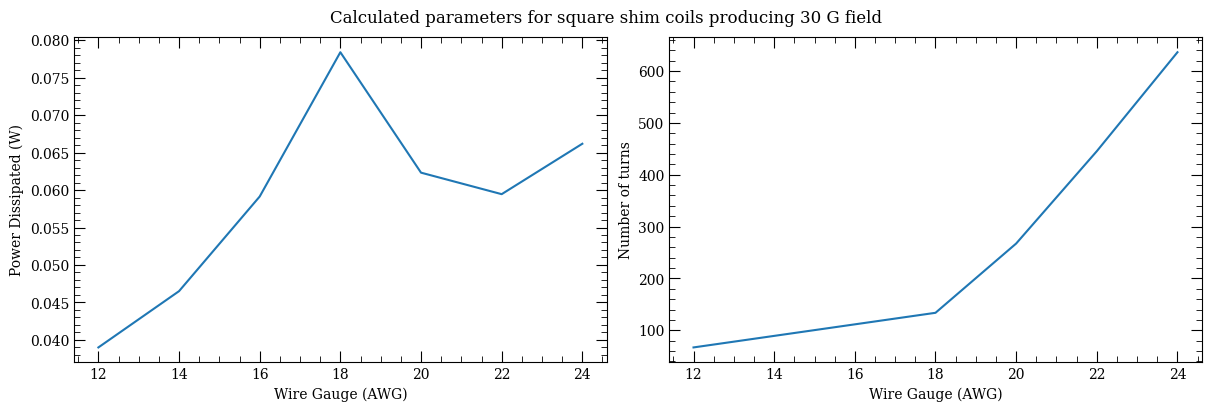

In [2]:
# We assume we'll use square coils (since they have the largest surface area + are easiest to wind)

def calculate_power(gauge, field):
    #Taken from: https://en.wikipedia.org/wiki/American_wire_gauge
    wire_gauge = [24,22,20,18,16,14,12] #AWG
    ampacity = [2.1, 3, 5, 10, 12, 15, 20] #Amps
    res_per_length = [84.22, 52.96, 33.31, 20.95, 13.17, 8.286, 5.211] #megaOhms/meter
    res_per_length = np.array(res_per_length)*1e-6 #Ohms/meter

    gi = wire_gauge.index(gauge)
    I_req = (490/11)*field #490 A was required to generate 11 G in the close configuration of the square coils
    turns = I_req / ampacity[gi] #Get number of turns required to generate the field
    wire_length = turns * (70e-3*4) #Length of one coil loop in the 490A 11G square coil configuration
    power = (ampacity[gi]**2)*(res_per_length[gi]*wire_length) # P = I^2 * R
    return power, turns

def plot_for_field(field):
    gauges = [24,22,20,18,16,14,12]
    powers = []
    turns = []
    for wg in gauges:
        p,t = calculate_power(wg, field)
        powers.append(p)
        turns.append(t)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    axes[0].plot(gauges, powers)
    axes[0].set_xlabel("Wire Gauge (AWG)")
    axes[0].set_ylabel("Power Dissipated (W)")
    
    axes[1].plot(gauges, turns)
    axes[1].set_xlabel("Wire Gauge (AWG)")
    axes[1].set_ylabel("Number of turns")

    fig.suptitle(f"Calculated parameters for square shim coils producing {field} G field")
    fig.show()

plot_for_field(30) #30 G is our worst case scenario, since our max field gradient is 30 G/cm